<a href="https://colab.research.google.com/github/specM7/DSGP-Test/blob/main/Test_DSGP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Directories for training and testing data
# train_dir = '/content/drive/MyDrive/Training'
train_dir = '/content/drive/MyDrive/new2'

# Define image size for VGG16
IMAGE_SIZE = 224


# # Load and shuffle the train data
# train_paths = []
# train_labels = []
# train_paths = []
# train_labels = []

# for label in os.listdir(train_dir):
#     label_path = os.path.join(train_dir, label)

#     # # Skip if this entry is not a directory
#     # if os.path.isdir(label_path)== False:
#     #     continue
#     train_paths.append(label_path)
#     train_labels.append(label_path)
train_paths = []
train_labels = []

for fname in os.listdir(train_dir):
    fname_lower = fname.lower()

    if not fname_lower.endswith(('.jpg', '.jpeg', '.png')):
        continue

    if 'tr-pi_' in fname_lower:
        label = 'pi'
    # elif 'tr-no_' in fname_lower:
    #     label = 'no'
    else:
        label = 'no'  # skip unknown files

    train_paths.append(os.path.join(train_dir, fname))
    train_labels.append(label)
from sklearn.model_selection import train_test_split

X_paths_train, X_paths_test, y_train, y_test = train_test_split(
    train_paths,
    train_labels,
    test_size=0.25,
    stratify=train_labels,   # ensures mix of pi & no
    random_state=42
)

print(f"Loaded {len(train_paths)} images")
print("Class distribution:")
from collections import Counter
print(Counter(train_labels))


Loaded 934 images
Class distribution:
Counter({'pi': 500, 'no': 434})


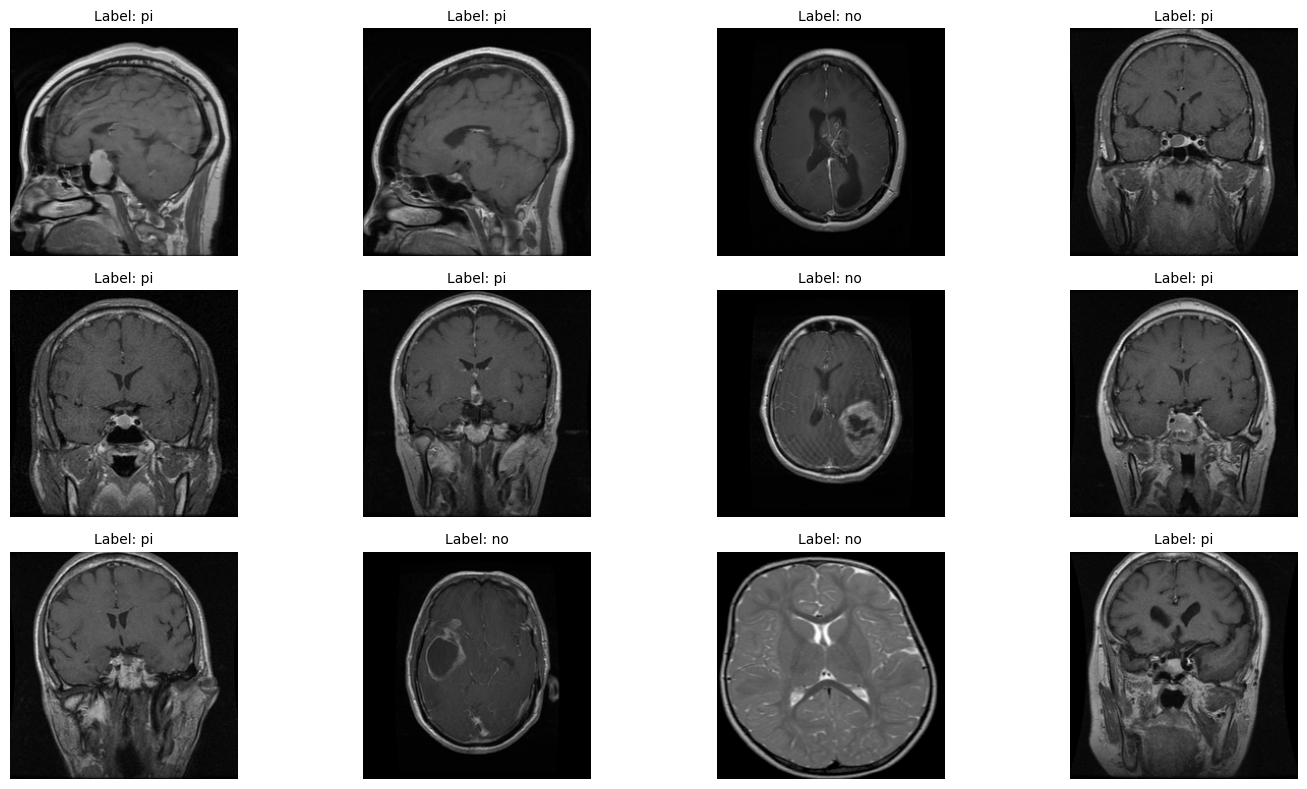

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
# random_indices = random.sample(range(len(train_paths)), 12)
num_images_to_show = min(12, len(train_paths))
random_indices = random.sample(range(len(train_paths)), num_images_to_show)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
axes = axes.ravel()

for i_display, idx_original in enumerate(random_indices):
    # Load image using the original index from train_paths
    img_path = train_paths[idx_original]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image on the i_display-th axis
    axes[i_display].imshow(img)
    axes[i_display].axis('off')  # Hide axis
    # Display class label
    axes[i_display].set_title(f"Label: {train_labels[idx_original]}", fontsize=10)

plt.tight_layout()
plt.show()

In [5]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    IMAGE_SIZE = 224

    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = np.array(image)
        image = augment_image(image)
        images.append(image)

    return np.array(images)


# Encoding labels (convert label names to integers)
def encode_label(labels):
    label_map = {'no': 0, 'pi': 1}
    return np.array([label_map[label] for label in labels])


# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

# Infinite data generator for Keras training loops
def infinite_datagen(paths, labels, batch_size=12):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels


In [6]:
# Load VGG16 model without top layers for feature extraction
def create_vgg16_feature_extractor():
    IMAGE_SIZE = 224
    vgg_base = VGG16(weights='imagenet',
                     include_top=False,
                     input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

    # Freeze all layers
    for layer in vgg_base.layers:
        layer.trainable = False

    return vgg_base

# Feature extraction function
def extract_features(paths, labels, vgg_model, batch_size=32):
    all_features = []
    all_encoded_labels = []

    # Encode all labels first
    encoded_labels = encode_label(labels)

    # Process in batches to avoid memory issues
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        batch_labels = encoded_labels[i:i + batch_size]

        # Load and preprocess images
        batch_images = open_images(batch_paths)

        # Extract features using VGG16
        features = vgg_model.predict(batch_images, verbose=0)
        features_flat = features.reshape(features.shape[0], -1)

        all_features.append(features_flat)
        all_encoded_labels.extend(batch_labels)

    # Combine all features
    all_features = np.vstack(all_features)
    all_encoded_labels = np.array(all_encoded_labels)
    print(f"All features shape: {all_features.shape}")
    print(all_encoded_labels)
    return all_features, all_encoded_labels

In [7]:
# Create and train the hybrid model
def create_hybrid_model(use_pca=True, pca_variance=0.95):
    # Create VGG16 feature extractor
    vgg_model = create_vgg16_feature_extractor()

    # Extract features from training and testing data
    X_train_feat, y_train_enc = extract_features(
        X_paths_train, y_train, vgg_model
    )

    X_test_feat, y_test_enc = extract_features(
        X_paths_test, y_test, vgg_model
    )

    print(f"Training features shape: {X_train_feat.shape}")
    print(f"Training labels shape: {y_train_enc.shape}")

    from sklearn.metrics import accuracy_score

    n_trees_options = [5, 10, 15, 30, 60]
    train_acc = []
    test_acc = []

    best_model = None
    best_test_acc = -1
    best_test_pred = None
    best_n_trees = None

    for n_trees in n_trees_options:
        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        )

        if use_pca:
            model = Pipeline([
                ('pca', PCA(n_components=pca_variance, random_state=42)),
                ('rf', rf)
            ])
        else:
            model = rf

        model.fit(X_train_feat, y_train_enc)

        train_pred = model.predict(X_train_feat)
        test_pred = model.predict(X_test_feat)

        train_acc.append(accuracy_score(y_train_enc, train_pred))
        test_acc.append(accuracy_score(y_test_enc, test_pred))

        if test_acc[-1] > best_test_acc:
            best_test_acc = test_acc[-1]
            best_model = model
            best_test_pred = test_pred
            best_n_trees = n_trees

        print(f"Trees: {n_trees}")
        print(f"  Train acc: {train_acc[-1]:.4f}")
        print(f"  Test acc : {test_acc[-1]:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(n_trees_options, train_acc, marker='o', label='Training Accuracy')
    plt.plot(n_trees_options, test_acc, marker='o', label='Testing Accuracy')
    plt.xlabel("Number of Trees (Epoch Proxy)")
    plt.ylabel("Accuracy")
    if use_pca:
        plt.title("Learning Curve: VGG16 + PCA + Random Forest")
    else:
        plt.title("Learning Curve: VGG16 + Random Forest")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nBest model: {best_n_trees} trees | Test acc: {best_test_acc:.4f}\n")

    print("\nSample predictions:\n")

    label_map = {0: "no", 1: "pi"}

    for i in range(min(15, len(X_paths_test))):
        pred_label = label_map[best_test_pred[i]]
        true_label = y_test[i]

        print(
            f"Image: {os.path.basename(X_paths_test[i])} | "
            f"Predicted: {pred_label} | Actual: {true_label}"
        )

    return vgg_model, best_model

# ====Using VGG and sequential models : 1st prototype====
#     # Model architecture
# IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
# base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# # Freeze all layers of the VGG16 base model
# for layer in base_model.layers:
#     layer.trainable = False

# # Set the last few layers of the VGG16 base model to be trainable
# base_model.layers[-2].trainable = True
# base_model.layers[-3].trainable = True
# base_model.layers[-4].trainable = True

# # Build the final model
# model = Sequential()
# model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
# model.add(base_model)  # Add VGG16 base model
# model.add(Flatten())  # Flatten the output of the base model
# model.add(Dropout(0.3))  # Dropout layer for regularization
# model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
# model.add(Dropout(0.2))  # Dropout layer for regularization
# model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# # Compile the model
# model.compile(optimizer=Adam(learning_rate=0.0001),
#               loss='sparse_categorical_crossentropy',
#               metrics=['sparse_categorical_accuracy'])

# # Parameters
# batch_size = 20
# steps = int(len(train_paths) / batch_size)  # Steps per epoch
# epochs = 5

# # Train the model
# history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
#                     epochs=epochs, steps_per_epoch=steps)


In [8]:
# Function to make predictions
def predict_images(paths, vgg_model, rf_classifier, batch_size=32):
    all_predictions = []
    all_probabilities = []

    label_map = {0: "no", 1: "pi"}

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]

        # Load and preprocess images
        batch_images = open_images(batch_paths)

        # Extract features using VGG16
        features = vgg_model.predict(batch_images, verbose=0)
        features_flat = features.reshape(features.shape[0], -1)

        # Make predictions
        batch_predictions = rf_classifier.predict(features_flat)
        batch_probabilities = rf_classifier.predict_proba(features_flat)

        # Decode predictions back to label names
        decoded_predictions = [label_map[pred] for pred in batch_predictions]

        all_predictions.extend(decoded_predictions)
        all_probabilities.append(batch_probabilities)

    all_probabilities = np.vstack(all_probabilities)
    return all_predictions, all_probabilities

# Build a lightweight CAM classifier on top of VGG16 for Grad-CAM
def create_cam_classifier(vgg_base, num_classes=2, learning_rate=1e-4):
    x = vgg_base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    cam_model = tf.keras.Model(inputs=vgg_base.input, outputs=outputs)
    cam_model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return cam_model

# Load image for Grad-CAM (no augmentation)
def load_image_for_vgg(path, image_size=224):
    img = Image.open(path).convert('RGB')
    img_resized = img.resize((image_size, image_size))
    img_array = np.array(img_resized).astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_resized, img_array

# Compute Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()

# Overlay heatmap on image
def overlay_heatmap(img, heatmap, alpha=0.4, colormap='jet'):
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_img = Image.fromarray(heatmap_uint8).resize(img.size)
    heatmap_color = plt.get_cmap(colormap)(np.array(heatmap_img) / 255.0)
    heatmap_color = np.uint8(heatmap_color[..., :3] * 255)
    heatmap_color_img = Image.fromarray(heatmap_color)
    return Image.blend(img.convert('RGB'), heatmap_color_img, alpha)


In [9]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def compute_training_accuracy(vgg_model, rf_classifier, paths, labels):
    features, encoded_labels = extract_features(paths, labels, vgg_model)
    predictions = rf_classifier.predict(features)
    accuracy = accuracy_score(encoded_labels, predictions)
    return accuracy


In [10]:
def plot_training_accuracy(accuracy):
    plt.figure(figsize=(6, 4))
    plt.plot([1], [accuracy], marker='o')
    plt.ylim(0, 1)
    plt.xticks([1], ['Training'])
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy of Hybrid VGG16 + Random Forest Model')
    plt.grid(True)
    plt.show()


In [11]:
import joblib

def save_model(vgg_model, rf_classifier, save_dir, cam_model=None):
    os.makedirs(save_dir, exist_ok=True)

    # Save Random Forest
    joblib.dump(rf_classifier, os.path.join(save_dir, "rf_classifier.pkl"))

    # Save VGG16
    vgg_model.save(os.path.join(save_dir, "vgg16_feature_extractor.keras"))

    # Save CAM classifier (optional)
    if cam_model is not None:
        cam_model.save(os.path.join(save_dir, "cam_classifier.keras"))

    print("Models saved successfully.")


In [12]:
from tensorflow.keras.models import load_model

def load_saved_model(save_dir):
    rf_classifier = joblib.load(os.path.join(save_dir, "rf_classifier.pkl"))
    vgg_model = load_model(os.path.join(save_dir, "vgg16_feature_extractor.keras"))

    cam_path = os.path.join(save_dir, "cam_classifier.keras")
    cam_model = load_model(cam_path) if os.path.exists(cam_path) else None

    print("Models loaded successfully.")
    return vgg_model, rf_classifier, cam_model


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
All features shape: (700, 25088)
[0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0
 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0
 1 0 1 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1
 1 1 0 1 1 1 0 0 1 1 0 1 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 1 0 1 1 1 0 0 0 1 0
 0 1 1 1 0 1 1 1 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 0 1 1 0 0 1 1 0 0 0 1 1 1 1
 0 1 0 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 1
 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 1 1 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0
 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 1 1 0 0 1 1 1 0
 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 0
 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0 1 1 0 1 1 0 1 1 0 1 0 1 0 0 0 1 0 1 0 1 1 1
 1 0 0 0 1 1 0 1

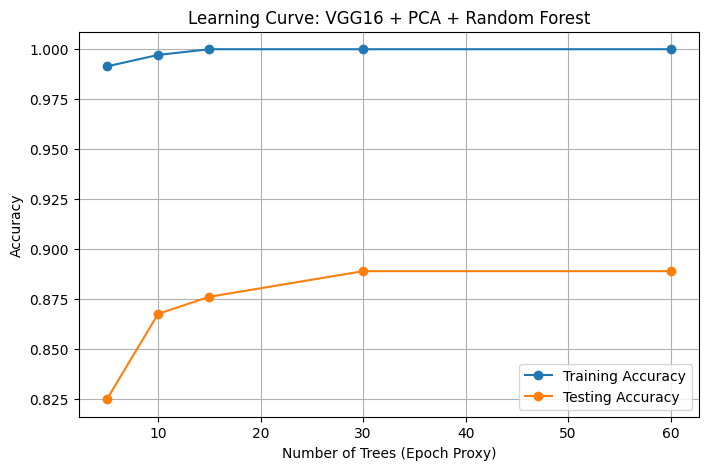


Best model: 30 trees | Test acc: 0.8889


Sample predictions:

Image: Tr-gl_0071.jpg | Predicted: no | Actual: no
Image: Tr-me_0061.jpg | Predicted: no | Actual: no
Image: Tr-pi_0385.jpg | Predicted: pi | Actual: pi
Image: Tr-me_0824.jpg | Predicted: no | Actual: no
Image: Tr-no_0049.jpg | Predicted: no | Actual: no
Image: Tr-pi_0053.jpg | Predicted: pi | Actual: pi
Image: Tr-me_0123.jpg | Predicted: pi | Actual: no
Image: Tr-pi_0473.jpg | Predicted: no | Actual: pi
Image: Tr-pi_0191.jpg | Predicted: pi | Actual: pi
Image: Tr-pi_0370.jpg | Predicted: pi | Actual: pi
Image: Tr-pi_0440.jpg | Predicted: pi | Actual: pi
Image: Tr-pi_0423.jpg | Predicted: pi | Actual: pi
Image: Tr-me_0082.jpg | Predicted: no | Actual: no
Image: Tr-no_0122.jpg | Predicted: no | Actual: no
Image: Tr-pi_0350.jpg | Predicted: pi | Actual: pi
Epoch 1/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 466s 11s/step - accuracy: 0.6037 - loss: 0.6740
Epoch 2/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 457s 10s/step - accuracy: 0.7730 - loss: 0.6029
E

In [13]:
# STEP 1: Create and train the hybrid model
vgg_model, rf_classifier = create_hybrid_model()

# STEP 2: Train a lightweight CAM classifier for Grad-CAM
cam_model = create_cam_classifier(vgg_model)
cam_epochs = 3
cam_batch_size = 16
cam_steps = int(np.ceil(len(X_paths_train) / cam_batch_size))

cam_model.fit(
    infinite_datagen(X_paths_train, y_train, batch_size=cam_batch_size),
    steps_per_epoch=cam_steps,
    epochs=cam_epochs
)


In [14]:
# STEP 3: Save model to Google Drive
MODEL_SAVE_PATH = "/content/drive/MyDrive/hybrid_vgg_rf_model"

save_model(vgg_model, rf_classifier, MODEL_SAVE_PATH, cam_model)

# STEP 4: Load saved model
vgg_model_loaded, rf_classifier_loaded, cam_model_loaded = load_saved_model(MODEL_SAVE_PATH)


Models saved successfully.
Models loaded successfully.


Saving Tr-pi_1434.jpg to Tr-pi_1434.jpg
Uploaded image: Tr-pi_1434.jpg


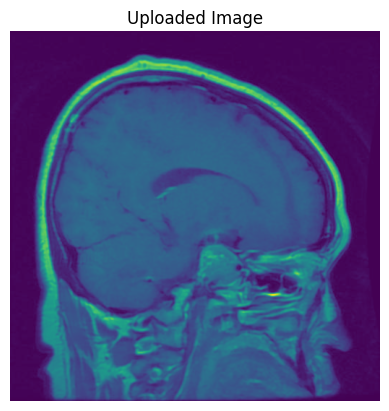

Models loaded successfully.

==================== PREDICTION ====================
 PREDICTION: PITUITARY TUMOR DETECTED
Confidence (Tumor Probability): 0.6333


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


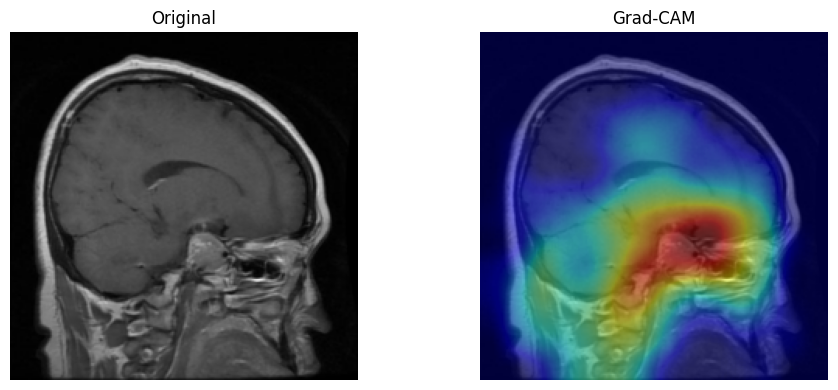

In [15]:
# UPLOAD IMAGE, PREDICT, AND SHOW GRAD-CAM HEATMAP


from google.colab import files
import os
from PIL import Image
import matplotlib.pyplot as plt

#  Upload image (any name, any type)
uploaded = files.upload()

# Get uploaded image path
image_path = list(uploaded.keys())[0]

print(f"Uploaded image: {image_path}")

#  Display the uploaded image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

#  Load the trained model(s)
vgg_model, rf_classifier, cam_model = load_saved_model(MODEL_SAVE_PATH)

# If CAM model is missing, train a quick one
if cam_model is None:
    print("CAM model not found. Training a quick CAM head for Grad-CAM...")
    cam_model = create_cam_classifier(vgg_model)
    cam_epochs = 2
    cam_batch_size = 16
    cam_steps = int(np.ceil(len(X_paths_train) / cam_batch_size))

    cam_model.fit(
        infinite_datagen(X_paths_train, y_train, batch_size=cam_batch_size),
        steps_per_epoch=cam_steps,
        epochs=cam_epochs
    )

#  Run prediction using EXISTING pipeline
predictions, probabilities = predict_images(
    paths=[image_path],      # wrap single image as list
    vgg_model=vgg_model,
    rf_classifier=rf_classifier
)

#  Interpret result
predicted_label = predictions[0]
tumor_probability = probabilities[0][1]  # probability of 'pi'

#  Output result
print("\n==================== PREDICTION ====================")

if predicted_label == 'pi':
    print(" PREDICTION: PITUITARY TUMOR DETECTED")
else:
    print(" PREDICTION: NO PITUITARY TUMOR DETECTED")

print(f"Confidence (Tumor Probability): {tumor_probability:.4f}")
print("====================================================")

#  Grad-CAM heatmap
last_conv_layer_name = "block5_conv3"
orig_img, img_array = load_image_for_vgg(image_path, IMAGE_SIZE)

class_index = 1 if predicted_label == 'pi' else 0
heatmap = make_gradcam_heatmap(
    img_array,
    cam_model,
    last_conv_layer_name,
    pred_index=class_index
)

overlay = overlay_heatmap(orig_img, heatmap, alpha=0.45)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig_img)
axes[0].axis('off')
axes[0].set_title("Original")

axes[1].imshow(overlay)
axes[1].axis('off')
axes[1].set_title("Grad-CAM")

plt.tight_layout()
plt.show()


In [16]:
# plt.figure(figsize=(8,4))
# plt.grid(True)
# plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
# plt.plot(history.history['loss'], '.r-', linewidth=2)
# plt.title('Model Training History')
# plt.xlabel('epoch')
# plt.xticks([x for x in range(epochs)])
# plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()